# Statistics Practical Project

## End-to-End Statistical Analysis Using Python

### Objective

This project demonstrates fundamental statistical concepts using a synthetic customer dataset.

The objective is to understand statistical concepts, implement them using Python, visualize the results, and derive practical insights from the data.

### Topics Covered

1. Population vs Sample
2. Sampling Techniques
3. Mean, Median, and Mode
4. Variance
5. Standard Deviation
6. Covariance
7. Correlation
8. Probability Basics
9. Conditional Probability
10. Bayes Theorem
11. Normal Distribution
12. Central Limit Theorem
13. Z-Score
14. Outliers
15. Confidence Interval

### Tools and Libraries

- Python
- Jupyter Notebook
- NumPy
- Pandas
- Matplotlib
- Seaborn
- SciPy
- Git
- GitHub

### Dataset

A synthetic customer dataset is created using Python for reproducible statistical analysis.

The dataset contains customer-level information such as age, income, spending, tenure, purchase frequency, satisfaction score, and churn status.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Make results reproducible
np.random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


In [14]:
# Reproducible dataset
np.random.seed(42)

# Number of customers
n = 1000

# Generate synthetic customer data
df = pd.DataFrame({
    "Customer_ID": [f"CUST_{i:04d}" for i in range(1, n + 1)],

    "Age": np.random.randint(18, 66, n),

    "Gender": np.random.choice(
        ["Male", "Female"],
        size=n
    ),

    "Region": np.random.choice(
        ["North", "South", "East", "West"],
        size=n
    ),

    "Monthly_Income": np.random.normal(
        loc=50000,
        scale=15000,
        size=n
    ),

    "Monthly_Spend": np.random.normal(
        loc=12000,
        scale=4000,
        size=n
    ),

    "Tenure_Months": np.random.randint(
        1, 61, n
    ),

    "Purchase_Frequency": np.random.randint(
        1, 16, n
    ),

    "Satisfaction_Score": np.random.randint(
        1, 11, n
    ),

    "Churn": np.random.choice(
        [0, 1],
        size=n,
        p=[0.75, 0.25]
    )
})

print("Dataset created successfully!")
print("Shape:", df.shape)

df.head()

Dataset created successfully!
Shape: (1000, 10)


,Customer_ID,Age,Gender,Region,Monthly_Income,Monthly_Spend,Tenure_Months,Purchase_Frequency,Satisfaction_Score,Churn
0,CUST_0001,56,Male,North,34023.295054,15355.762002,52,7,1,0
1,CUST_0002,46,Female,South,45421.629435,9530.987254,8,1,2,1
2,CUST_0003,32,Male,South,40857.316968,9766.792984,42,15,5,0
3,CUST_0004,60,Female,West,47195.430455,7599.383068,26,1,3,0
4,CUST_0005,25,Male,East,50849.748873,13758.004922,48,1,2,0


In [15]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Region', 'Monthly_Income',
       'Monthly_Spend', 'Tenure_Months', 'Purchase_Frequency',
       'Satisfaction_Score', 'Churn'],
      dtype='str')

In [16]:
print("Tenure range:",
      df["Tenure_Months"].min(),
      "to",
      df["Tenure_Months"].max())

print("Purchase frequency range:",
      df["Purchase_Frequency"].min(),
      "to",
      df["Purchase_Frequency"].max())

print("Satisfaction range:",
      df["Satisfaction_Score"].min(),
      "to",
      df["Satisfaction_Score"].max())

print("Churn values:",
      sorted(df["Churn"].unique()))

Tenure range: 1 to 60
Purchase frequency range: 1 to 15
Satisfaction range: 1 to 10
Churn values: [np.int64(0), np.int64(1)]


In [17]:
print("Negative income:", (df["Monthly_Income"] < 0).sum())
print("Negative spend:", (df["Monthly_Spend"] < 0).sum())

Negative income: 0
Negative spend: 0


In [18]:
df.to_csv("../data/synthetic_customer_data.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [19]:
import os

print(
    "File exists:",
    os.path.exists("../data/synthetic_customer_data.csv")
)

File exists: True


In [20]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 1000
Columns: 10


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1000 non-null   str    
 1   Age                 1000 non-null   int32  
 2   Gender              1000 non-null   str    
 3   Region              1000 non-null   str    
 4   Monthly_Income      1000 non-null   float64
 5   Monthly_Spend       1000 non-null   float64
 6   Tenure_Months       1000 non-null   int32  
 7   Purchase_Frequency  1000 non-null   int32  
 8   Satisfaction_Score  1000 non-null   int32  
 9   Churn               1000 non-null   int64  
dtypes: float64(2), int32(4), int64(1), str(3)
memory usage: 62.6 KB


In [22]:
df.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Region                0
Monthly_Income        0
Monthly_Spend         0
Tenure_Months         0
Purchase_Frequency    0
Satisfaction_Score    0
Churn                 0
dtype: int64

# 1. Population vs Sample

## Concept

A **population** represents the complete group that we are interested in studying.

A **sample** is a smaller subset selected from the population.

In this project:

- The complete dataset of 1,000 customers can be treated as the population.
- A subset of customers can be selected as a sample.
- Statistical measures calculated from the population are called population statistics.
- Statistical measures calculated from a sample are called sample statistics.

Sampling is useful when analyzing the complete population is expensive, time-consuming, or impractical.

In [23]:
# Select a random sample of 100 customers

sample_df = df.sample(
    n=100,
    random_state=42
)

print("Population size:", len(df))
print("Sample size:", len(sample_df))

Population size: 1000
Sample size: 100


In [24]:
print("Population mean age:", df["Age"].mean())
print("Sample mean age:", sample_df["Age"].mean())

Population mean age: 41.575
Sample mean age: 42.06


### Interpretation

The population contains all 1,000 customers, while the sample contains only 100 randomly selected customers.

The sample mean age is expected to be reasonably close to the population mean age, but it may not be exactly the same.

This demonstrates an important statistical principle: a well-selected random sample can provide useful information about a larger population without requiring analysis of every individual observation.

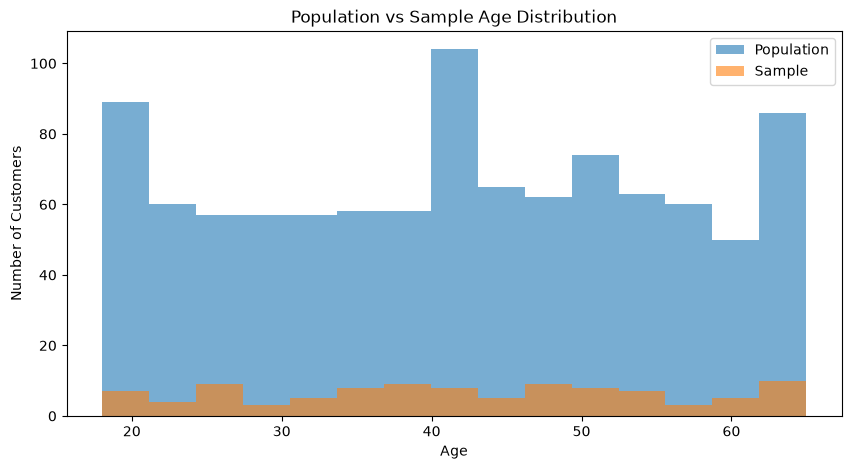

In [26]:
# Compare population and sample age distributions

plt.figure(figsize=(10, 5))

plt.hist(
    df["Age"],
    bins=15,
    alpha=0.6,
    label="Population"
)

plt.hist(
    sample_df["Age"],
    bins=15,
    alpha=0.6,
    label="Sample"
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Population vs Sample Age Distribution")
plt.legend()

plt.show()

### Visualization Insight

The population and sample age distributions show a similar overall pattern.

Although the sample contains only 100 customers compared with 1,000 customers in the population, the sample provides a reasonable representation of the population's age distribution.

This demonstrates why random sampling can be useful for statistical analysis.

# 2. Sampling Techniques

## Concept

Sampling is the process of selecting a subset of observations from a larger population.

Different sampling techniques can be used depending on the objective of the analysis.

Common sampling techniques include:

1. Simple Random Sampling
2. Systematic Sampling
3. Stratified Sampling
4. Cluster Sampling

In this project, we will demonstrate simple random sampling, systematic sampling, and stratified sampling using the synthetic customer dataset.

### 2.1 Simple Random Sampling

In simple random sampling, every observation in the population has an equal chance of being selected.

We previously used this technique with `df.sample()` to randomly select 100 customers from the population of 1,000 customers.

In [27]:
# Simple Random Sampling

random_sample = df.sample(
    n=100,
    random_state=42
)

print("Population size:", len(df))
print("Sample size:", len(random_sample))

random_sample.head()

Population size: 1000
Sample size: 100


,Customer_ID,Age,Gender,Region,Monthly_Income,Monthly_Spend,Tenure_Months,Purchase_Frequency,Satisfaction_Score,Churn
521,CUST_0522,27,Female,East,51628.395587,18503.835661,23,15,8,1
737,CUST_0738,50,Female,North,45444.109568,8864.985916,2,5,2,0
740,CUST_0741,49,Female,North,42856.686897,9777.812882,58,6,10,1
660,CUST_0661,25,Female,South,66861.690800,17054.826711,4,10,2,1
411,CUST_0412,39,Female,West,62120.866974,17365.903662,9,9,2,0


### 2.2 Systematic Sampling

In systematic sampling, observations are selected at a fixed interval from the population.

For example, if we want to select every 10th customer, we can use a sampling interval of 10.

This method is simple and useful when the data is organized in a sequence.

In [28]:
# Systematic Sampling

sampling_interval = 10

systematic_sample = df.iloc[::sampling_interval]

print("Population size:", len(df))
print("Systematic sample size:", len(systematic_sample))

systematic_sample.head()

Population size: 1000
Systematic sample size: 100


,Customer_ID,Age,Gender,Region,Monthly_Income,Monthly_Spend,Tenure_Months,Purchase_Frequency,Satisfaction_Score,Churn
0,CUST_0001,56,Male,North,34023.295054,15355.762002,52,7,1,0
10,CUST_0011,28,Male,North,35909.969093,7633.196495,28,11,7,1
20,CUST_0021,47,Female,East,40798.960047,14002.662886,31,6,9,1
30,CUST_0031,59,Female,South,11691.182976,10084.650176,43,8,1,0
40,CUST_0041,26,Female,East,41806.333276,10522.891443,35,1,9,0


### 2.3 Stratified Sampling

In stratified sampling, the population is divided into groups called strata.

A sample is then selected from each group.

For this dataset, we can use `Region` as the stratification variable.

This ensures that customers from different regions are represented in the sample.

In [31]:
# Stratified Sampling by Region

stratified_sample = (
    df.groupby("Region", group_keys=False)
      .sample(n=25, random_state=42)
      .reset_index(drop=True)
)

print("Population size:", len(df))
print("Stratified sample size:", len(stratified_sample))

print("\nRegion distribution in stratified sample:")
print(stratified_sample["Region"].value_counts())

Population size: 1000
Stratified sample size: 100

Region distribution in stratified sample:
Region
East     25
North    25
South    25
West     25
Name: count, dtype: int64


# 3. Mean, Median, and Mode

## Concept

Measures of central tendency describe the center or typical value of a dataset.

The three common measures are:

### Mean

The mean is the arithmetic average of all observations.

It is calculated as:

Mean = Sum of all values / Number of observations

### Median

The median is the middle value when the observations are arranged in ascending or descending order.

The median is less affected by extreme values than the mean.

### Mode

The mode is the value that occurs most frequently in a dataset.

These measures help us understand the typical characteristics of a variable.

In [33]:
# Mean, Median, and Mode of Customer Age

mean_age = df["Age"].mean()
median_age = df["Age"].median()
mode_age = df["Age"].mode()[0]

print("Mean Age:", mean_age)
print("Median Age:", median_age)
print("Mode Age:", mode_age)

Mean Age: 41.575
Median Age: 42.0
Mode Age: 43


### Interpretation

The average customer age is 41.575 years, while the median age is 42 years.

The mode is 43 years, meaning that age occurs more frequently than any other age in the dataset.

The mean and median are relatively close, suggesting that the distribution of customer ages does not have a strong skew.

These measures provide different perspectives on the typical age of customers.

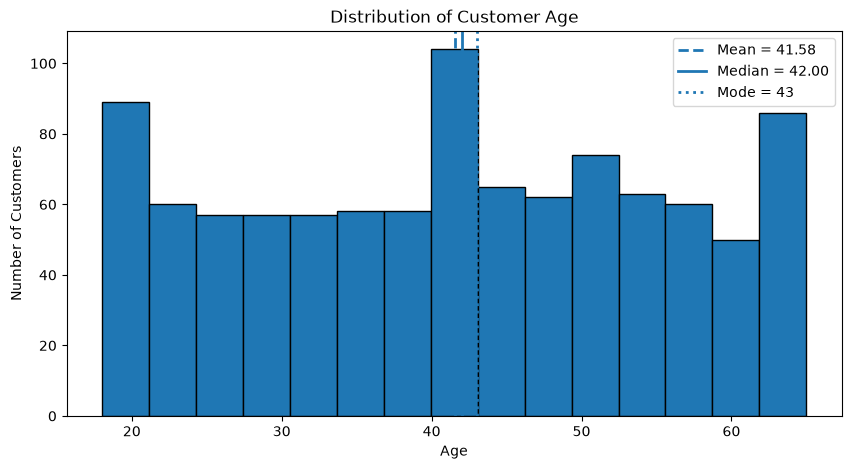

In [34]:
# Visualize the distribution of customer age

plt.figure(figsize=(10, 5))

plt.hist(
    df["Age"],
    bins=15,
    edgecolor="black"
)

plt.axvline(
    mean_age,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_age:.2f}"
)

plt.axvline(
    median_age,
    linestyle="-",
    linewidth=2,
    label=f"Median = {median_age:.2f}"
)

plt.axvline(
    mode_age,
    linestyle=":",
    linewidth=2,
    label=f"Mode = {mode_age}"
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Age")
plt.legend()

plt.show()

### Visualization Insight

The histogram shows the distribution of customer ages across the dataset.

The mean, median, and mode are located relatively close to each other, indicating that the center of the age distribution is around the early forties.

The visualization makes it easier to understand where the majority of customer ages are concentrated.

# 4. Variance

## Concept

Variance measures how much the values in a dataset spread out from the mean.

A small variance means that the observations are relatively close to the mean.

A large variance means that the observations are more spread out.

Variance is calculated differently for a population and a sample:

- **Population variance** uses the complete population.
- **Sample variance** estimates the population variance using a sample.

In Python:

- `ddof=0` calculates population variance.
- `ddof=1` calculates sample variance.

Variance is expressed in squared units of the original variable.

In [35]:
# Calculate population and sample variance of customer age

population_variance = df["Age"].var(ddof=0)
sample_variance = df["Age"].var(ddof=1)

print("Population Variance:", population_variance)
print("Sample Variance:", sample_variance)

Population Variance: 189.304375
Sample Variance: 189.49386886886887


### Interpretation

The population variance of customer age is 189.304375, while the sample variance is 189.493869.

The two values are very close because the sample is reasonably large compared with the population.

The variance indicates the amount of dispersion in customer ages around the mean age.

Because variance is expressed in squared units, standard deviation provides a more intuitive measure of the typical spread of customer ages.

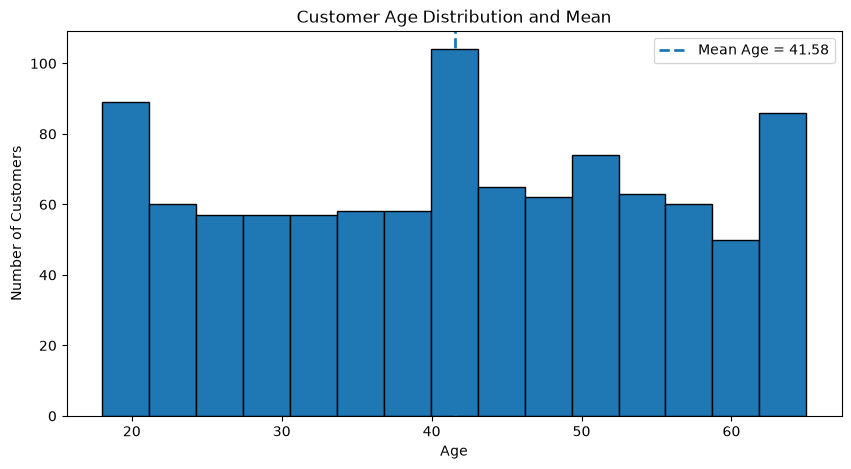

In [36]:
# Visualize customer age and mean

plt.figure(figsize=(10, 5))

plt.hist(
    df["Age"],
    bins=15,
    edgecolor="black"
)

plt.axvline(
    df["Age"].mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean Age = {df['Age'].mean():.2f}"
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution and Mean")
plt.legend()

plt.show()

### Visualization Insight

The histogram shows how customer ages are distributed around the mean age of 41.575 years.

The spread of observations around the mean contributes to the variance. Customers whose ages are farther from the mean contribute more to the overall variance because the deviations are squared.

The visualization helps demonstrate why variance is a measure of dispersion.

# 5. Standard Deviation

## Concept

Standard deviation measures how much the observations in a dataset typically vary from the mean.

A small standard deviation means that the observations are generally close to the mean.

A large standard deviation means that the observations are more spread out from the mean.

Standard deviation is the square root of variance.

In Python:

- `ddof=0` calculates population standard deviation.
- `ddof=1` calculates sample standard deviation.

Unlike variance, standard deviation is expressed in the same units as the original variable, making it easier to interpret.

In [37]:
# Calculate population and sample standard deviation of customer age

population_std = df["Age"].std(ddof=0)
sample_std = df["Age"].std(ddof=1)

print("Population Standard Deviation:", population_std)
print("Sample Standard Deviation:", sample_std)

Population Standard Deviation: 13.758792643251805
Sample Standard Deviation: 13.76567720342406


In [38]:
# Verify that standard deviation is the square root of variance

print(
    "Square root of population variance:",
    np.sqrt(population_variance)
)

print(
    "Population standard deviation:",
    population_std
)

Square root of population variance: 13.758792643251805
Population standard deviation: 13.758792643251805


### Interpretation

The population standard deviation represents the typical amount by which customer ages vary from the mean age of 41.575 years.

Because the standard deviation is expressed in years, it is easier to interpret than variance.

A standard deviation of approximately 13.76 years indicates that customer ages typically vary by around 13.76 years from the mean age.

The population and sample standard deviations are very close because the sample-size adjustment has only a small effect with a large dataset.

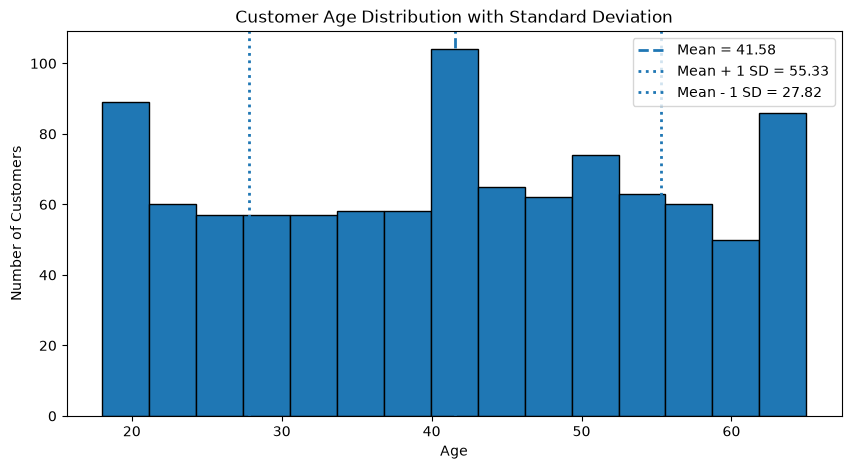

In [39]:
# Visualize customer age distribution with standard deviation

mean_age = df["Age"].mean()

plt.figure(figsize=(10, 5))

plt.hist(
    df["Age"],
    bins=15,
    edgecolor="black"
)

plt.axvline(
    mean_age,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_age:.2f}"
)

plt.axvline(
    mean_age + population_std,
    linestyle=":",
    linewidth=2,
    label=f"Mean + 1 SD = {mean_age + population_std:.2f}"
)

plt.axvline(
    mean_age - population_std,
    linestyle=":",
    linewidth=2,
    label=f"Mean - 1 SD = {mean_age - population_std:.2f}"
)

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution with Standard Deviation")
plt.legend()

plt.show()

### Visualization Insight

The histogram shows how customer ages are distributed around the mean age.

The lines representing one standard deviation above and below the mean illustrate the spread of customer ages.

A larger distance from the mean indicates greater variability, while observations closer to the mean indicate lower variability.

The visualization makes standard deviation easier to understand because it shows the spread using the original unit of measurement: years.

# 6. Covariance

## Concept

Covariance measures the direction of the relationship between two variables.

It tells us whether two variables tend to increase or decrease together.

- **Positive covariance** means that the variables tend to increase together.
- **Negative covariance** means that when one variable increases, the other tends to decrease.
- **Covariance close to zero** suggests little linear co-movement between the variables.

In this project, we will examine the covariance between Monthly Income and Monthly Spend.

Covariance indicates the direction of a relationship, but its magnitude depends on the units of the variables. Therefore, covariance is not ideal for comparing relationships between variables with different scales.

In [40]:
# Calculate covariance between Monthly Income and Monthly Spend

covariance_income_spend = df["Monthly_Income"].cov(
    df["Monthly_Spend"]
)

print(
    "Covariance between Monthly Income and Monthly Spend:",
    covariance_income_spend
)

Covariance between Monthly Income and Monthly Spend: 1718761.6029937055


In [41]:
# Covariance matrix

covariance_matrix = df[
    ["Monthly_Income", "Monthly_Spend"]
].cov()

covariance_matrix

,Monthly_Income,Monthly_Spend
Monthly_Income,2.213108e+08,1.718762e+06
Monthly_Spend,1.718762e+06,1.586866e+07


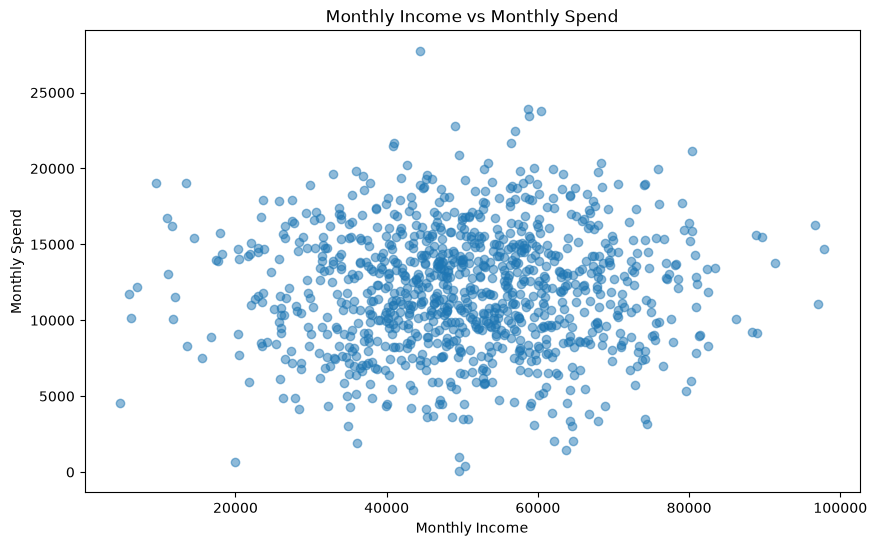

In [42]:
# Visualize Monthly Income vs Monthly Spend

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Monthly_Income"],
    df["Monthly_Spend"],
    alpha=0.5
)

plt.xlabel("Monthly Income")
plt.ylabel("Monthly Spend")
plt.title("Monthly Income vs Monthly Spend")

plt.show()

### Interpretation

The covariance between Monthly Income and Monthly Spend is approximately 1,718,761.60.

Since the covariance is positive, Monthly Income and Monthly Spend tend to move in the same direction in this synthetic dataset.

This suggests that customers with higher monthly income generally tend to have higher monthly spending.

However, covariance alone does not tell us the strength of the relationship because its magnitude depends on the units and scale of the variables.

Therefore, correlation will be used in the next section to measure the strength and direction of the relationship on a standardized scale.

### Visualization Insight

The scatter plot shows the relationship between Monthly Income and Monthly Spend.

The points show a generally positive pattern, indicating that customers with higher monthly income tend to have higher monthly spending.

However, the points are not perfectly aligned, which indicates that other factors may also influence customer spending.

The scatter plot provides a visual explanation for the positive covariance observed between the two variables.

# 7. Correlation

## Concept

Correlation measures the strength and direction of the linear relationship between two variables.

The correlation coefficient ranges from -1 to +1.

- **+1** indicates a perfect positive linear relationship.
- **0** indicates no linear relationship.
- **-1** indicates a perfect negative linear relationship.

Unlike covariance, correlation is standardized and does not depend on the units of measurement.

In this project, we will calculate the correlation between Monthly Income and Monthly Spend.

In [43]:
# Calculate correlation between Monthly Income and Monthly Spend

correlation_income_spend = df["Monthly_Income"].corr(
    df["Monthly_Spend"]
)

print(
    "Correlation between Monthly Income and Monthly Spend:",
    correlation_income_spend
)

Correlation between Monthly Income and Monthly Spend: 0.029003088699913047


### Interpretation

The correlation between Monthly Income and Monthly Spend is approximately **0.029**.

Since the value is very close to 0, there is a **very weak positive linear relationship** between Monthly Income and Monthly Spend in this synthetic dataset.

This means that higher income does not strongly correspond to higher monthly spending in the generated data.

Correlation measures the strength of a **linear relationship**, so a correlation close to zero does not necessarily mean that there is no relationship of any kind between the variables.

Compared with covariance, correlation is easier to interpret because it is standardized and always ranges from -1 to +1.

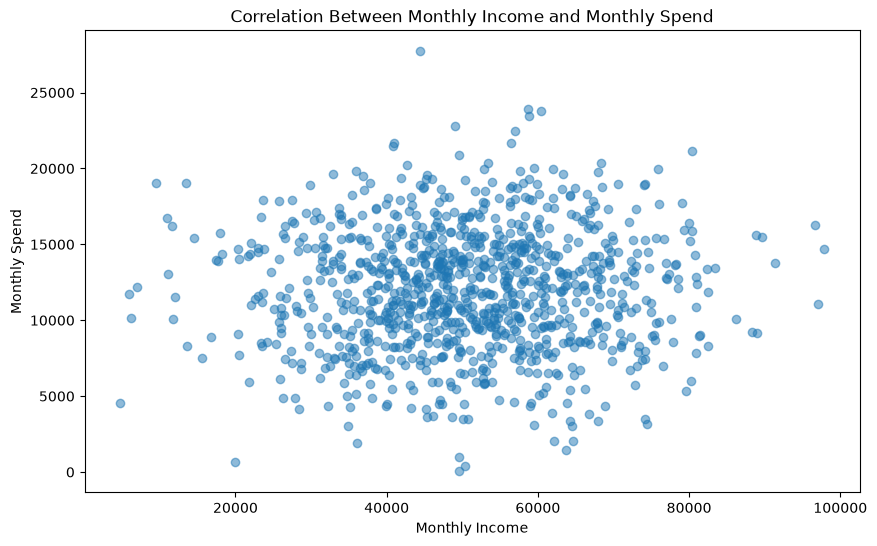

In [44]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Monthly_Income"],
    df["Monthly_Spend"],
    alpha=0.5
)

plt.xlabel("Monthly Income")
plt.ylabel("Monthly Spend")
plt.title("Correlation Between Monthly Income and Monthly Spend")

plt.show()

### Visualization Insight

The scatter plot shows the relationship between Monthly Income and Monthly Spend.

The points are widely scattered and do not form a clear upward or downward pattern.

This visual pattern is consistent with the correlation value of approximately 0.029, which indicates a very weak linear relationship between the two variables.

The plot also shows that customers with similar income levels can have different spending levels, suggesting that other factors may influence customer spending.

The visualization helps demonstrate why correlation is useful for measuring the strength and direction of a linear relationship.

# 8. Probability Basics

## Concept

Probability measures how likely an event is to occur.

The probability of an event ranges from 0 to 1:

- **0** means the event is impossible.
- **1** means the event is certain.
- A probability between 0 and 1 represents the likelihood of the event occurring.

Probability can also be expressed as a percentage.

The basic probability formula is:

Probability = Number of favorable outcomes / Total number of possible outcomes

In this project, we will calculate the probability of a customer being classified as a churned customer.

In [45]:
# Calculate the probability of a customer being churned

churned_customers = (df["Churn"] == 1).sum()
total_customers = len(df)

probability_churn = churned_customers / total_customers

print("Number of churned customers:", churned_customers)
print("Total customers:", total_customers)
print("Probability of churn:", probability_churn)
print("Probability of churn (%):", probability_churn * 100)

Number of churned customers: 254
Total customers: 1000
Probability of churn: 0.254
Probability of churn (%): 25.4


### Interpretation

The probability of a randomly selected customer being churned is **0.254**, or **25.4%**.

This means that approximately 25 out of every 100 customers in this dataset are classified as churned.

Probability provides a simple way to quantify the likelihood of an event occurring.

In a real-world business scenario, this churn probability could be used as a baseline measure for understanding customer retention and identifying areas where further analysis may be useful.

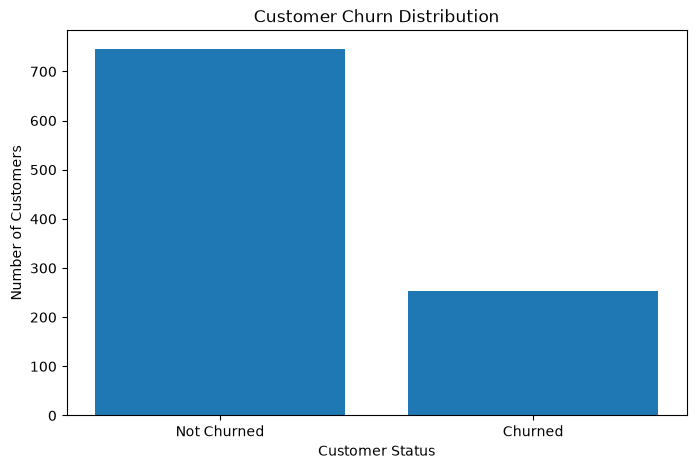

In [46]:
# Visualize churn probability

churn_counts = df["Churn"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Not Churned", "Churned"],
    churn_counts.values
)

plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")

plt.show()

### Visualization Insight

The bar chart shows the distribution of churned and non-churned customers.

There are 746 customers who are not churned and 254 customers who are churned.

The chart clearly shows that the majority of customers are not churned, while approximately 25.4% of customers are classified as churned.

This visualization provides a simple representation of the probability calculated above and makes the difference between the two customer groups easy to understand.

# 9. Conditional Probability

## Concept

Conditional probability measures the probability of an event occurring given that another event has already occurred.

It is written as:

P(A | B)

This means:

"Probability of A given B."

The basic formula is:

P(A | B) = P(A and B) / P(B)

In this project, we will calculate the probability that a customer has churned given that the customer has a low satisfaction score.

We will define a low satisfaction score as a score less than or equal to 5.

In [47]:
# Identify customers with low satisfaction

low_satisfaction = df["Satisfaction_Score"] <= 5
churned = df["Churn"] == 1

low_satisfaction_count = low_satisfaction.sum()
churned_and_low_satisfaction = (low_satisfaction & churned).sum()

print("Customers with low satisfaction:", low_satisfaction_count)
print("Churned customers with low satisfaction:", churned_and_low_satisfaction)

Customers with low satisfaction: 508
Churned customers with low satisfaction: 126


In [48]:
# Calculate conditional probability:
# P(Churn | Low Satisfaction)

conditional_probability = (
    churned_and_low_satisfaction / low_satisfaction_count
)

print(
    "P(Churn | Low Satisfaction):",
    conditional_probability
)

print(
    "Probability of churn given low satisfaction (%):",
    conditional_probability * 100
)

P(Churn | Low Satisfaction): 0.24803149606299213
Probability of churn given low satisfaction (%): 24.803149606299215


### Interpretation

The conditional probability of churn given low satisfaction is approximately **0.248**, or **24.8%**.

This means that among customers with a satisfaction score of 5 or below, approximately 24.8% are classified as churned.

Conditional probability is useful because it allows us to calculate the likelihood of an event within a specific group rather than across the entire population.

In this dataset, the overall probability of churn is 25.4%, while the probability of churn among low-satisfaction customers is approximately 24.8%.

This comparison shows that low satisfaction alone does not result in a substantially higher churn probability in this synthetic dataset.

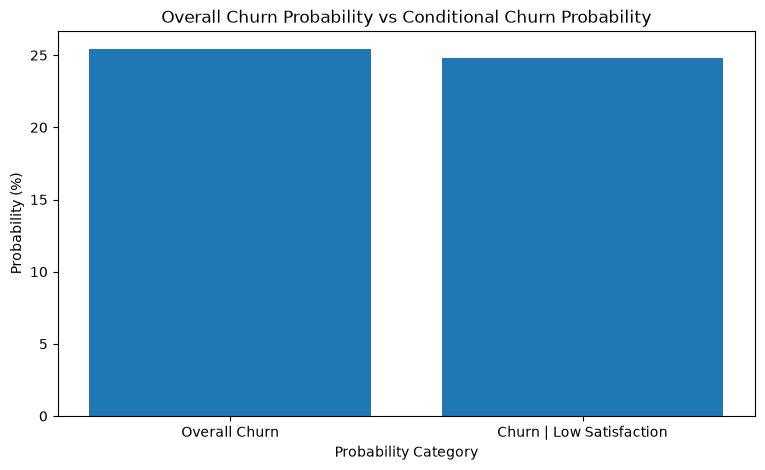

In [49]:
# Compare overall churn probability with conditional churn probability

probability_comparison = pd.DataFrame({
    "Category": [
        "Overall Churn",
        "Churn | Low Satisfaction"
    ],
    "Probability": [
        probability_churn * 100,
        conditional_probability * 100
    ]
})

plt.figure(figsize=(9, 5))

plt.bar(
    probability_comparison["Category"],
    probability_comparison["Probability"]
)

plt.xlabel("Probability Category")
plt.ylabel("Probability (%)")
plt.title("Overall Churn Probability vs Conditional Churn Probability")

plt.show()

### Visualization Insight

The bar chart compares the overall probability of churn with the probability of churn among customers with low satisfaction.

The overall churn probability is 25.4%, while the conditional probability of churn given low satisfaction is approximately 24.8%.

The two probabilities are very close, which indicates that low satisfaction alone does not substantially increase the probability of churn in this synthetic dataset.

The visualization makes the comparison between the overall probability and conditional probability easy to understand.

# 10. Bayes Theorem

## Concept

Bayes Theorem is used to calculate the probability of an event based on prior knowledge of related events.

It is especially useful when we want to reverse a conditional probability.

The Bayes Theorem formula is:

P(A | B) = [P(B | A) × P(A)] / P(B)

Where:

- **P(A | B)** = Probability of A given B
- **P(B | A)** = Probability of B given A
- **P(A)** = Prior probability of A
- **P(B)** = Probability of B

In this project:

- **A = Customer churn**
- **B = Low satisfaction score (≤ 5)**

We will use Bayes Theorem to calculate the probability of churn given low satisfaction and compare it with the direct conditional probability calculated in the previous section.

In [50]:
# Calculate probabilities required for Bayes Theorem

prob_churn = (df["Churn"] == 1).mean()

prob_low_satisfaction = (
    df["Satisfaction_Score"] <= 5
).mean()

prob_low_given_churn = (
    (df["Satisfaction_Score"] <= 5) & (df["Churn"] == 1)
).sum() / (df["Churn"] == 1).sum()

print("P(Churn):", prob_churn)
print("P(Low Satisfaction):", prob_low_satisfaction)
print("P(Low Satisfaction | Churn):", prob_low_given_churn)

P(Churn): 0.254
P(Low Satisfaction): 0.508
P(Low Satisfaction | Churn): 0.49606299212598426


In [51]:
# Calculate P(Churn | Low Satisfaction) using Bayes Theorem

bayes_probability = (
    prob_low_given_churn * prob_churn
) / prob_low_satisfaction

print(
    "P(Churn | Low Satisfaction) using Bayes Theorem:",
    bayes_probability
)

print(
    "Probability (%):",
    bayes_probability * 100
)

P(Churn | Low Satisfaction) using Bayes Theorem: 0.24803149606299213
Probability (%): 24.803149606299215


### Interpretation

Bayes Theorem gives a probability of approximately **0.248**, or **24.8%**, for a customer being churned given that the customer has low satisfaction.

This result is exactly the same as the conditional probability calculated directly in the previous section.

This demonstrates how Bayes Theorem can be used to derive a conditional probability from other known probabilities.

In this example:

- P(Churn) = 25.4%
- P(Low Satisfaction) = 50.8%
- P(Low Satisfaction | Churn) ≈ 49.6%
- P(Churn | Low Satisfaction) ≈ 24.8%

The result shows how prior probability and observed evidence can be combined to calculate a revised probability.

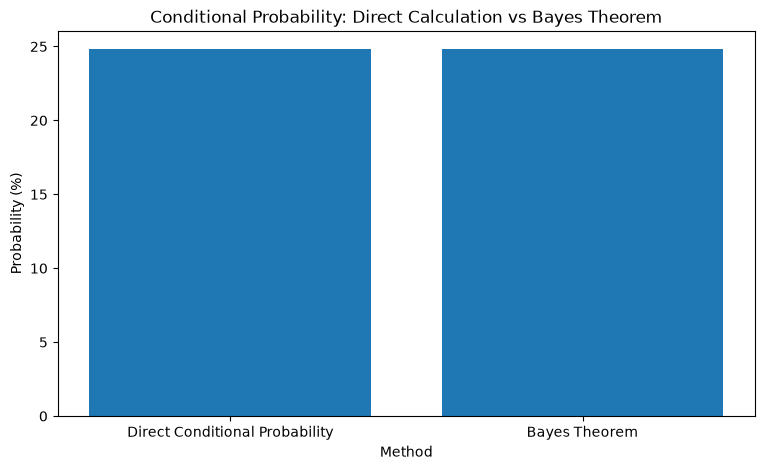

In [52]:
# Compare direct conditional probability with Bayes Theorem result

bayes_comparison = pd.DataFrame({
    "Method": [
        "Direct Conditional Probability",
        "Bayes Theorem"
    ],
    "Probability": [
        conditional_probability * 100,
        bayes_probability * 100
    ]
})

plt.figure(figsize=(9, 5))

plt.bar(
    bayes_comparison["Method"],
    bayes_comparison["Probability"]
)

plt.xlabel("Method")
plt.ylabel("Probability (%)")
plt.title("Conditional Probability: Direct Calculation vs Bayes Theorem")

plt.show()

### Visualization Insight

The bar chart shows that the direct conditional probability and the probability calculated using Bayes Theorem are identical, both approximately 24.8%.

This confirms that Bayes Theorem correctly reproduces the conditional probability when the required probabilities are known.

The visualization demonstrates the relationship between direct probability calculation and Bayes-based probability calculation.

# 11. Normal Distribution

## Concept

The normal distribution is a continuous probability distribution that is symmetric around its mean.

It is commonly represented by a bell-shaped curve.

In a normal distribution:

- The mean, median, and mode are equal.
- Most observations are concentrated around the mean.
- Fewer observations occur as we move farther away from the mean.

The spread of a normal distribution is controlled by its standard deviation.

In this project, we will examine the distribution of customer age and compare it with a normal distribution curve.

In [53]:
# Calculate mean and standard deviation of customer age

age_mean = df["Age"].mean()
age_std = df["Age"].std()

print("Mean Age:", age_mean)
print("Standard Deviation of Age:", age_std)

Mean Age: 41.575
Standard Deviation of Age: 13.76567720342406


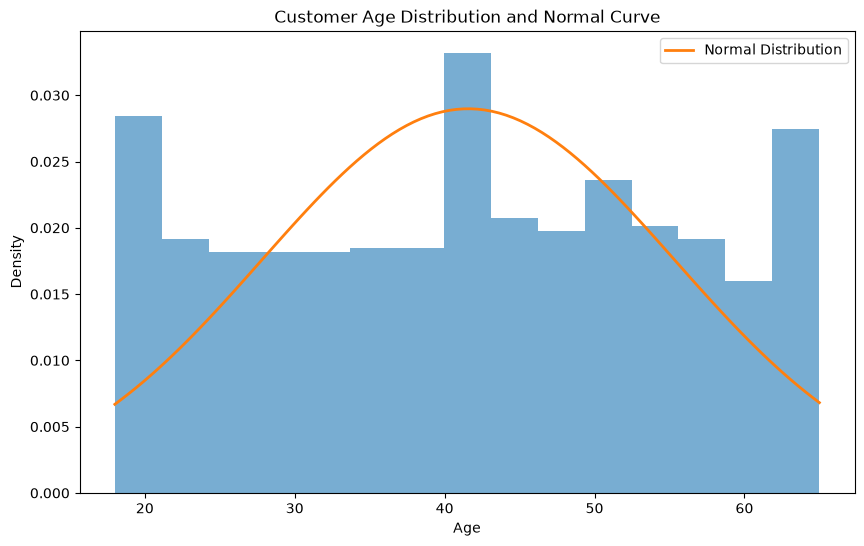

In [54]:
# Plot customer age distribution with a normal distribution curve

x = np.linspace(
    df["Age"].min(),
    df["Age"].max(),
    100
)

normal_curve = stats.norm.pdf(
    x,
    age_mean,
    age_std
)

plt.figure(figsize=(10, 6))

plt.hist(
    df["Age"],
    bins=15,
    density=True,
    alpha=0.6
)

plt.plot(
    x,
    normal_curve,
    linewidth=2,
    label="Normal Distribution"
)

plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Customer Age Distribution and Normal Curve")
plt.legend()

plt.show()

### Interpretation

The customer age distribution is centered around a mean age of approximately 41.6 years.

The normal distribution curve provides a theoretical bell-shaped reference for comparing the observed age distribution with a normal distribution.

The observed data shows some variation around the theoretical curve, which is expected because the customer ages are generated from synthetic data and may not perfectly follow a normal distribution.

The mean and standard deviation describe the center and spread of the distribution.

### Visualization Insight

The histogram shows the distribution of customer ages, while the smooth curve represents a theoretical normal distribution using the same mean and standard deviation.

The comparison helps us visually assess how closely the observed age distribution resembles a normal distribution.

The distribution is concentrated around the middle age range, with fewer observations toward the lower and higher age ranges.

# 12. Central Limit Theorem

## Concept

The Central Limit Theorem states that when sufficiently large random samples are repeatedly taken from a population, the distribution of the sample means tends to become approximately normal.

This is true even when the original population is not perfectly normally distributed.

The Central Limit Theorem is important because it allows statistical inference about population parameters using sample data.

In this project, we will repeatedly sample customer ages and examine the distribution of the sample means.

In [55]:
# Generate sample means

sample_means = []

for _ in range(1000):
    sample = df["Age"].sample(
        n=30,
        random_state=None
    )
    sample_means.append(sample.mean())

print("Number of sample means:", len(sample_means))
print("Mean of sample means:", np.mean(sample_means))
print("Population mean:", df["Age"].mean())

Number of sample means: 1000
Mean of sample means: 41.686566666666664
Population mean: 41.575


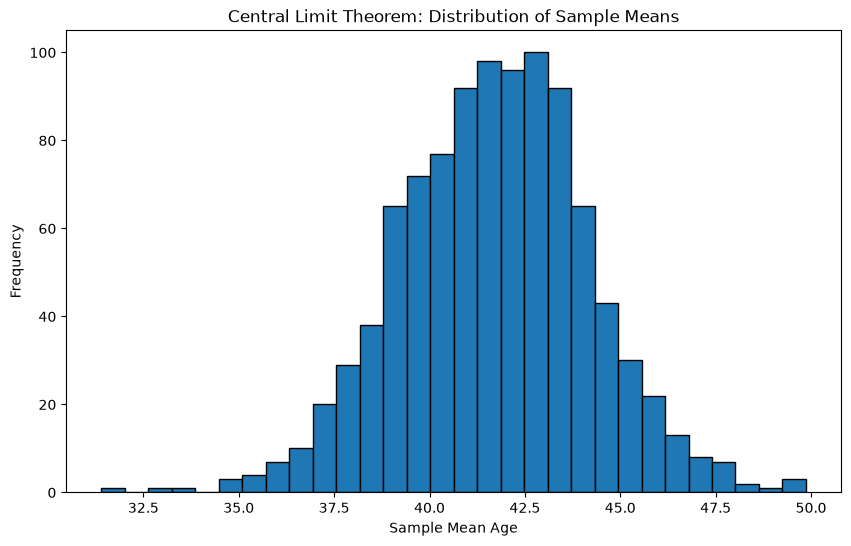

In [56]:
plt.figure(figsize=(10, 6))

plt.hist(
    sample_means,
    bins=30,
    edgecolor="black"
)

plt.xlabel("Sample Mean Age")
plt.ylabel("Frequency")
plt.title("Central Limit Theorem: Distribution of Sample Means")

plt.show()

### Interpretation

The distribution of sample means is approximately bell-shaped.

The mean of the sample means is close to the population mean of customer age.

This demonstrates the Central Limit Theorem: repeated samples of sufficient size produce a sampling distribution of the mean that tends toward a normal distribution.

The Central Limit Theorem provides the foundation for many statistical inference techniques.

### Visualization Insight

The histogram of sample means is more concentrated around the population mean than the distribution of individual customer ages.

This occurs because averaging observations reduces the effect of individual variation.

The approximately bell-shaped distribution demonstrates the Central Limit Theorem in practice.

# 13. Z-Score

## Concept

A Z-score indicates how many standard deviations an observation is away from the mean.

The formula is:

Z = (X - Mean) / Standard Deviation

A positive Z-score means that the observation is above the mean.

A negative Z-score means that the observation is below the mean.

A Z-score close to zero means that the observation is close to the mean.

Z-scores are useful for comparing observations and identifying unusually high or low values.

In [57]:
# Calculate Z-score for the first customer's age

customer_age = df["Age"].iloc[0]

age_z_score = (
    customer_age - df["Age"].mean()
) / df["Age"].std()

print("Customer Age:", customer_age)
print("Z-Score:", age_z_score)

Customer Age: 56
Z-Score: 1.04789613956747


In [58]:
# Calculate Z-scores for all customer ages

df["Age_Z_Score"] = stats.zscore(df["Age"])

df[["Customer_ID", "Age", "Age_Z_Score"]].head()

,Customer_ID,Age,Age_Z_Score
0,CUST_0001,56,1.048420
1,CUST_0002,46,0.321613
2,CUST_0003,32,-0.695919
3,CUST_0004,60,1.339144
4,CUST_0005,25,-1.204684


### Interpretation

The Z-score indicates how far a customer's age is from the average customer age in terms of standard deviations.

A positive Z-score indicates an age above the population mean, while a negative Z-score indicates an age below the mean.

For example, the first customer's age of 56 years has a positive Z-score, meaning that the customer is older than the average customer in the dataset.

Z-scores provide a standardized way to compare observations relative to the overall distribution.

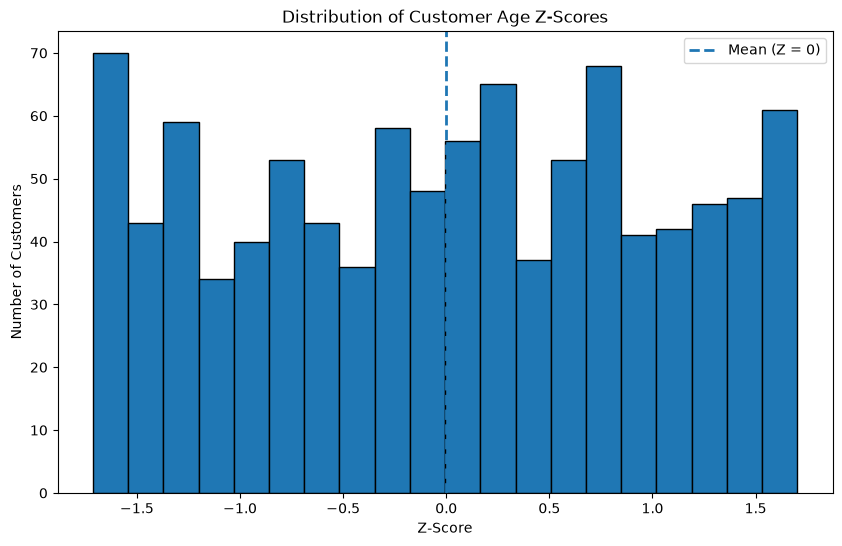

In [59]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Age_Z_Score"],
    bins=20,
    edgecolor="black"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=2,
    label="Mean (Z = 0)"
)

plt.xlabel("Z-Score")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Age Z-Scores")
plt.legend()

plt.show()

### Visualization Insight

The histogram shows the distribution of standardized customer age values.

Most observations are concentrated around a Z-score of zero, which represents the mean age.

Values farther from zero represent customers whose ages differ more substantially from the average.

# 14. Outliers

## Concept

An outlier is an observation that is unusually far from the rest of the data.

One common method for detecting outliers is the Interquartile Range (IQR) method.

The IQR is calculated as:

IQR = Q3 - Q1

The lower boundary is:

Q1 - 1.5 × IQR

The upper boundary is:

Q3 + 1.5 × IQR

Observations outside these boundaries can be considered potential outliers.

In this project, we will identify potential outliers in Monthly Spend.

In [60]:
# Detect outliers in Monthly Spend using the IQR method

Q1 = df["Monthly_Spend"].quantile(0.25)
Q3 = df["Monthly_Spend"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Monthly_Spend"] < lower_bound) |
    (df["Monthly_Spend"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of potential outliers:", len(outliers))

Q1: 9171.696401215926
Q3: 14726.130597041463
IQR: 5554.434195825537
Lower Bound: 840.0451074776211
Upper Bound: 23057.78189077977
Number of potential outliers: 7


C:\Users\tadij\AppData\Local\Temp\ipykernel_12136\2509343203.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


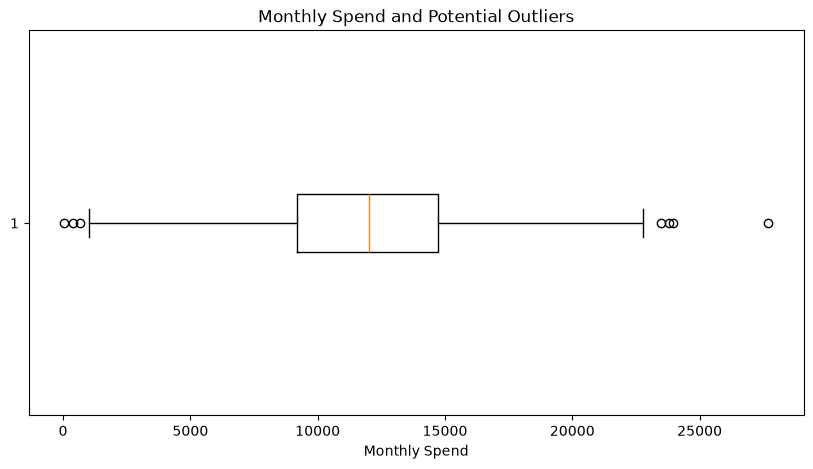

In [61]:
plt.figure(figsize=(10, 5))

plt.boxplot(
    df["Monthly_Spend"],
    vert=False
)

plt.xlabel("Monthly Spend")
plt.title("Monthly Spend and Potential Outliers")

plt.show()

### Interpretation

The IQR method identifies observations that fall substantially below or above the central range of Monthly Spend.

These observations are classified as potential outliers because they fall outside the calculated lower and upper IQR boundaries.

Outliers should not automatically be removed. They may represent genuine customer behavior, unusual transactions, or data-quality issues.

Therefore, potential outliers should be investigated before deciding whether they should be excluded from an analysis.

### Visualization Insight

The box plot shows the central distribution of Monthly Spend along with observations that fall outside the typical range.

Points beyond the whiskers represent potential outliers according to the box plot's definition.

The visualization provides a quick way to identify unusually low or high spending values.

# 15. Confidence Interval

## Concept

A confidence interval provides a range of plausible values for a population parameter based on sample data.

Instead of reporting only a single estimate, a confidence interval provides an estimated range together with a confidence level.

In this project, we will calculate a 95% confidence interval for the mean customer age.

A 95% confidence interval means that the method used to construct the interval would capture the true population mean in approximately 95% of repeated samples under the assumptions of the method.

In [62]:
# Calculate a 95% confidence interval for mean customer age

sample_age = df["Age"]

confidence_level = 0.95

confidence_interval = stats.t.interval(
    confidence_level,
    df=len(sample_age) - 1,
    loc=sample_age.mean(),
    scale=stats.sem(sample_age)
)

print("Sample Mean Age:", sample_age.mean())
print("95% Confidence Interval:", confidence_interval)

Sample Mean Age: 41.575
95% Confidence Interval: (np.float64(40.72077522849717), np.float64(42.42922477150284))


### Interpretation

The sample mean customer age is approximately 41.6 years.

The 95% confidence interval provides a range of plausible values for the population mean customer age.

The interval accounts for sampling variability rather than relying only on the sample mean.

A narrower confidence interval indicates a more precise estimate, while a wider interval indicates greater uncertainty around the estimated population mean.

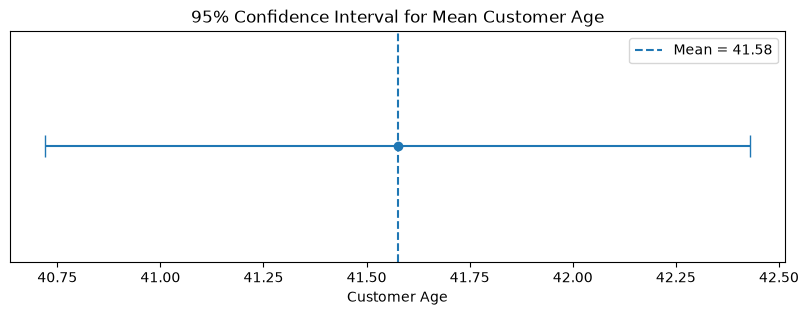

In [63]:
# Visualize the confidence interval

mean_age = sample_age.mean()
lower_ci, upper_ci = confidence_interval

plt.figure(figsize=(10, 3))

plt.errorbar(
    mean_age,
    0,
    xerr=[
        [mean_age - lower_ci],
        [upper_ci - mean_age]
    ],
    fmt="o",
    capsize=8
)

plt.axvline(
    mean_age,
    linestyle="--",
    label=f"Mean = {mean_age:.2f}"
)

plt.xlabel("Customer Age")
plt.yticks([])
plt.title("95% Confidence Interval for Mean Customer Age")
plt.legend()

plt.show()

### Visualization Insight

The visualization shows the sample mean customer age together with its 95% confidence interval.

The point represents the estimated mean, while the horizontal error bar represents the range of plausible values around the estimate.

The confidence interval provides more information than the sample mean alone because it communicates the uncertainty associated with estimating a population parameter from sample data.

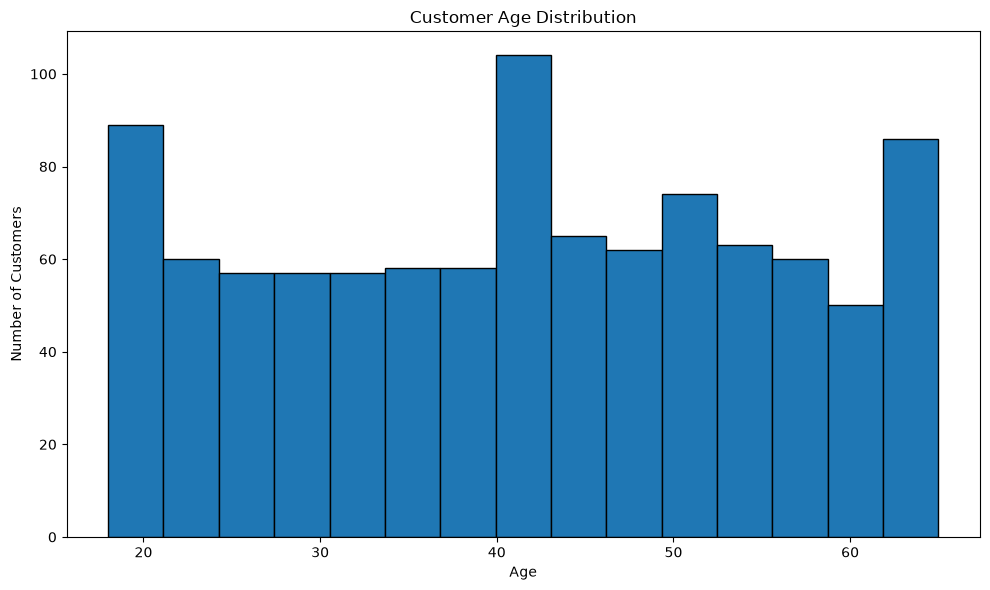

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df["Age"], bins=15, edgecolor="black")

plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.title("Customer Age Distribution")

plt.tight_layout()
plt.savefig("../outputs/statistics_figures.png", dpi=300, bbox_inches="tight")
plt.show()